# TechFlow SaaS — KPI & Retention Analysis

**Project**: Portfolio Project 1 — Product KPI Dashboard + A/B Test Analysis  
**Dataset**: IBM Telco Customer Churn (7,043 rows) reframed as a SaaS subscription dataset  
**Tools**: Python · pandas · matplotlib · seaborn · scikit-learn

---

## Business Context

TechFlow is a B2B SaaS company with three subscription plans:
- **Month-to-month** (Starter) — flexible, no commitment
- **One year** (Growth) — annual contract
- **Two year** (Enterprise) — two-year contract

The Head of Product has asked for an analysis of:
1. How MRR is distributed across plans
2. Where customers are churning — and why
3. Which customers are most at risk right now

---

## How to run this notebook

**Option A — Local** (if you ran `tools/setup_db.py`):  
The processed CSVs are already in `../data/processed/`. Just run all cells.

**Option B — Google Colab**:  
Uncomment and run the *Colab setup* cell below, then run the rest normally.

In [1]:
# ── COLAB SETUP (skip if running locally) ─────────────────────────────────────
# Uncomment the lines below if you're in Google Colab.
# They download the processed CSV files directly from GitHub.

# import urllib.request, pathlib
# BASE = "https://raw.githubusercontent.com/YOUR_GITHUB_USERNAME/Data_Analyst_Projects/main"
# BASE += "/project1_saas_analytics/data/processed"
# files = [
#     "q1_customers_by_plan.csv", "q2_mrr_by_plan.csv",
#     "q5_churn_by_lifecycle.csv", "q6_ltv_by_lifecycle.csv",
# ]
# pathlib.Path("../data/processed").mkdir(parents=True, exist_ok=True)
# for f in files:
#     urllib.request.urlretrieve(f"{BASE}/{f}", f"../data/processed/{f}")
# print("Files downloaded.")

# Also need the raw telco CSV for the full analysis:
# urllib.request.urlretrieve(
#     "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv",
#     "../data/raw/telco_churn.csv"
# )
print("Colab setup: skipped (running locally)")

Colab setup: skipped (running locally)


In [2]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# Chart style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROCESSED = Path("../data/processed")
RAW       = Path("../data/raw")

print("Imports OK")

Imports OK


In [3]:
# ── LOAD DATA ─────────────────────────────────────────────────────────────────
import re

df = pd.read_csv(RAW / "telco_churn.csv")

# Step 1: explicit renames (Telco → SaaS framing)
df = df.rename(columns={
    "customerID":     "customer_id",
    "tenure":         "subscription_months",
    "MonthlyCharges": "monthly_mrr",
    "TotalCharges":   "lifetime_value",
    "Contract":       "plan_type",
    "Churn":          "churned",
})

# Step 2: convert remaining CamelCase to snake_case
# e.g. PaymentMethod → payment_method, InternetService → internet_service
df.columns = [
    re.sub(r'(?<=[a-z])(?=[A-Z])', '_', c).lower()
    for c in df.columns
]

# lifetime_value has ~11 blank strings (brand-new customers) — convert to NaN
df["lifetime_value"] = pd.to_numeric(df["lifetime_value"], errors="coerce")

# Convenience: numeric churn flag (1 = churned, 0 = active)
df["churned_flag"] = (df["churned"] == "Yes").astype(int)

# Lifecycle stage (matches SQL Q4)
df["lifecycle_stage"] = pd.cut(
    df["subscription_months"],
    bins=[-1, 6, 24, 999],
    labels=["new (0-6mo)", "growing (7-24mo)", "mature (25mo+)"]
)

print(f"Loaded {len(df):,} customers")
print("Column names:", list(df.columns))
df.head(3)

Loaded 7,043 customers
Column names: ['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'subscription_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'plan_type', 'paperless_billing', 'payment_method', 'monthly_mrr', 'lifetime_value', 'churned', 'churned_flag', 'lifecycle_stage']


,customer_id,gender,senior_citizen,partner,dependents,subscription_months,phone_service,multiple_lines,internet_service,online_security,...,streaming_tv,streaming_movies,plan_type,paperless_billing,payment_method,monthly_mrr,lifetime_value,churned,churned_flag,lifecycle_stage
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,new (0-6mo)
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,mature (25mo+)
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,new (0-6mo)


---
## 1. Data Quality Check

Before any analysis, I check for:
- Missing values
- Unexpected data types
- Class imbalance (churn vs. active)


In [4]:
# ── DATA QUALITY ──────────────────────────────────────────────────────────────
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("Missing values: none")
else:
    print("Missing values:")
    print(missing.to_string())

print()

# Class balance
churn_counts = df["churned"].value_counts()
churn_rate   = df["churned_flag"].mean()
print(f"Active customers:  {churn_counts.get('No', 0):,}")
print(f"Churned customers: {churn_counts.get('Yes', 0):,}")
print(f"Overall churn rate: {churn_rate:.1%}")

print()

# Key numeric stats
print(df[["subscription_months", "monthly_mrr", "lifetime_value"]]
      .describe()
      .round(2)
      .to_string())

Shape: 7,043 rows × 23 columns

Missing values:
lifetime_value    11

Active customers:  5,174
Churned customers: 1,869
Overall churn rate: 26.5%

       subscription_months  monthly_mrr  lifetime_value
count              7043.00      7043.00         7032.00
mean                 32.37        64.76         2283.30
std                  24.56        30.09         2266.77
min                   0.00        18.25           18.80
25%                   9.00        35.50          401.45
50%                  29.00        70.35         1397.48
75%                  55.00        89.85         3794.74
max                  72.00       118.75         8684.80


---
## 2. MRR by Plan Type

**Business question**: Where does our monthly recurring revenue come from?

Month-to-month customers pay a higher monthly rate but churn more.  
Multi-year contracts lock in lower MRR but higher lifetime value.

> *This is the same as SQL Q2 — here we're doing it in python pandas.*

     plan_type  customers  total_mrr   avg_mrr
Month-to-month       3875  257294.15 66.398490
      Two year       1695  103005.85 60.770413
      One year       1473   95816.60 65.048608


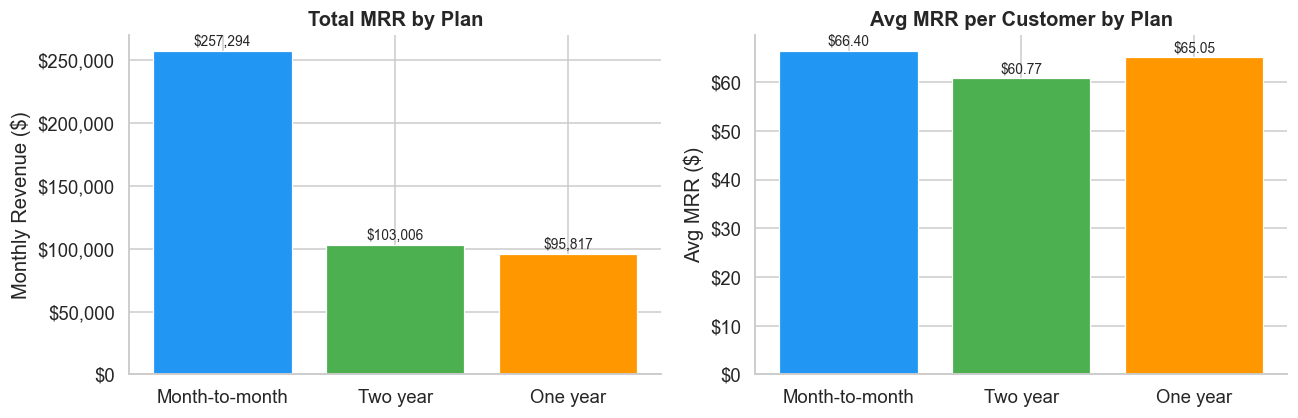

In [5]:
# ── MRR BY PLAN ───────────────────────────────────────────────────────────────
mrr_by_plan = (
    df.groupby("plan_type", observed=True)
    .agg(
        customers    = ("customer_id",  "count"),
        total_mrr    = ("monthly_mrr",  "sum"),
        avg_mrr      = ("monthly_mrr",  "mean"),
    )
    .sort_values("total_mrr", ascending=False)
    .reset_index()
)

print(mrr_by_plan.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: total MRR
bars = axes[0].bar(
    mrr_by_plan["plan_type"],
    mrr_by_plan["total_mrr"],
    color=["#2196F3", "#4CAF50", "#FF9800"],
    edgecolor="white", linewidth=0.8
)
axes[0].set_title("Total MRR by Plan", fontweight="bold")
axes[0].set_ylabel("Monthly Revenue ($)")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=9)

# Right: avg MRR per customer
bars2 = axes[1].bar(
    mrr_by_plan["plan_type"],
    mrr_by_plan["avg_mrr"],
    color=["#2196F3", "#4CAF50", "#FF9800"],
    edgecolor="white", linewidth=0.8
)
axes[1].set_title("Avg MRR per Customer by Plan", fontweight="bold")
axes[1].set_ylabel("Avg MRR ($)")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:.0f}"))
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"${bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/fig_mrr_by_plan.png", bbox_inches="tight")
plt.show()

---
## 3. Churn Analysis

**Business question**: Where are we losing customers — and at what rate?

We'll look at churn through three lenses:
1. By **plan type** — which plan retains customers best?
2. By **lifecycle stage** — when do customers leave?
3. By **payment method** — does payment friction predict churn?

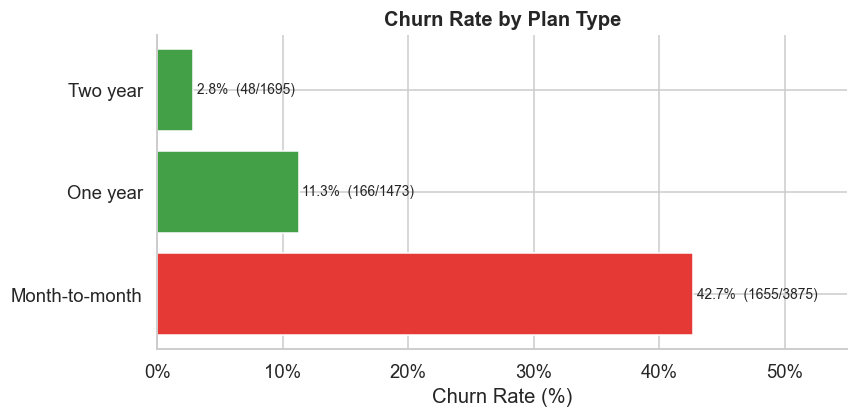

     plan_type  churned  total  churn_rate
Month-to-month     1655   3875    0.427097
      One year      166   1473    0.112695
      Two year       48   1695    0.028319


In [6]:
# ── CHURN BY PLAN TYPE ────────────────────────────────────────────────────────
churn_plan = (
    df.groupby("plan_type", observed=True)["churned_flag"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "churned", "count": "total", "mean": "churn_rate"})
    .sort_values("churn_rate", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#E53935" if r > 0.3 else "#FFA726" if r > 0.15 else "#43A047"
          for r in churn_plan["churn_rate"]]
bars = ax.barh(churn_plan["plan_type"], churn_plan["churn_rate"] * 100,
               color=colors, edgecolor="white")
ax.set_xlabel("Churn Rate (%)")
ax.set_title("Churn Rate by Plan Type", fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, (_, row) in zip(bars, churn_plan.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row['churn_rate']:.1%}  ({int(row['churned'])}/{int(row['total'])})",
            va="center", fontsize=9)
ax.set_xlim(0, 55)
plt.tight_layout()
plt.savefig("../data/processed/fig_churn_by_plan.png", bbox_inches="tight")
plt.show()
print(churn_plan.to_string(index=False))

Churn rate by lifecycle stage:
 lifecycle_stage  churned  total  churn_rate
     new (0-6mo)      784   1481    0.529372
growing (7-24mo)      547   1729    0.316368
  mature (25mo+)      538   3833    0.140360


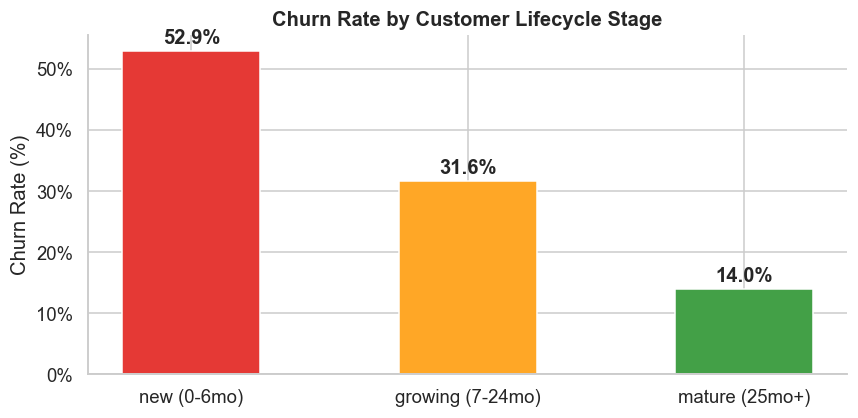

In [7]:
# ── CHURN BY LIFECYCLE STAGE ──────────────────────────────────────────────────
# This is the most actionable view: it shows WHEN customers churn.

churn_lifecycle = (
    df.groupby("lifecycle_stage", observed=True)["churned_flag"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "churned", "count": "total", "mean": "churn_rate"})
    .reset_index()
)

print("Churn rate by lifecycle stage:")
print(churn_lifecycle.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
stage_colors = ["#E53935", "#FFA726", "#43A047"]
bars = ax.bar(
    churn_lifecycle["lifecycle_stage"].astype(str),
    churn_lifecycle["churn_rate"] * 100,
    color=stage_colors,
    edgecolor="white", width=0.5
)
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Customer Lifecycle Stage", fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/fig_churn_by_lifecycle.png", bbox_inches="tight")
plt.show()

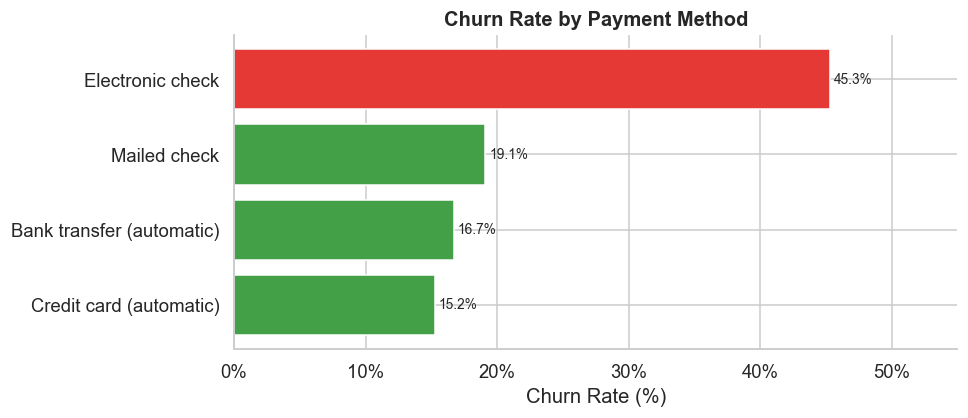

In [8]:
# ── CHURN BY PAYMENT METHOD ───────────────────────────────────────────────────
churn_payment = (
    df.groupby("payment_method", observed=True)["churned_flag"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "churned", "count": "total", "mean": "churn_rate"})
    .sort_values("churn_rate", ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#E53935" if r > 0.3 else "#FFA726" if r > 0.2 else "#43A047"
          for r in churn_payment["churn_rate"]]
bars = ax.barh(churn_payment["payment_method"], churn_payment["churn_rate"] * 100,
               color=colors, edgecolor="white")
ax.set_xlabel("Churn Rate (%)")
ax.set_title("Churn Rate by Payment Method", fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, (_, row) in zip(bars, churn_payment.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row['churn_rate']:.1%}", va="center", fontsize=9)
ax.set_xlim(0, 55)
plt.tight_layout()
plt.savefig("../data/processed/fig_churn_by_payment.png", bbox_inches="tight")
plt.show()

---
## 4. Cohort Retention Heatmap

**Business question**: How does retention drop off over the customer lifetime?

A retention heatmap shows what % of customers from each "tenure bucket" are still active.  
Darker = more churn. The goal is to keep the heatmap as light as possible.

Since we have a snapshot dataset (not time-series events), we'll build a **synthetic cohort**  
by grouping customers into 6-month tenure buckets and comparing churn rates across them.

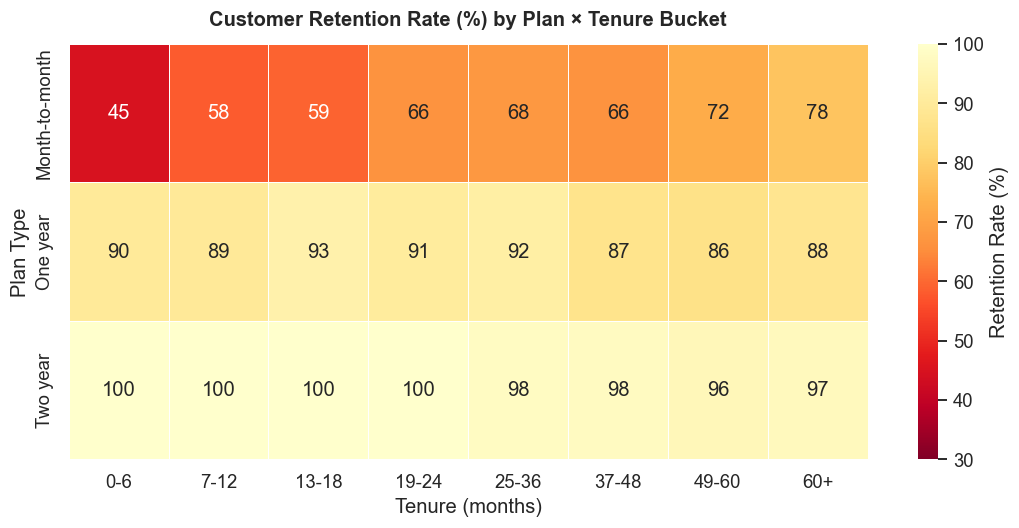


Retention rates (100% = zero churn in that bucket):
plan_type      Month-to-month  One year  Two year
tenure_bucket                                    
0-6                      44.8      89.7     100.0
7-12                     58.0      89.4     100.0
13-18                    59.1      93.3     100.0
19-24                    66.5      90.7     100.0
25-36                    67.5      92.0      97.9
37-48                    66.5      86.9      97.8
49-60                    72.2      86.3      96.0
60+                      77.8      87.9      96.9


In [9]:
# ── COHORT RETENTION HEATMAP ──────────────────────────────────────────────────

# Create 6-month tenure buckets
bucket_labels = ["0-6", "7-12", "13-18", "19-24", "25-36", "37-48", "49-60", "60+"]
df["tenure_bucket"] = pd.cut(
    df["subscription_months"],
    bins=[0, 6, 12, 18, 24, 36, 48, 60, 999],
    labels=bucket_labels,
    include_lowest=True
)

# Retention rate = 1 - churn rate, by tenure bucket × plan type
pivot = (
    df.groupby(["tenure_bucket", "plan_type"], observed=True)["churned_flag"]
    .mean()
    .unstack("plan_type")
    .mul(100)        # → percentage
    .round(1)
)

# Retention = 100 - churn rate
retention = 100 - pivot

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    retention.T,
    annot=True, fmt=".0f", cmap="YlOrRd_r",
    vmin=30, vmax=100,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Retention Rate (%)"},
    ax=ax
)
ax.set_title("Customer Retention Rate (%) by Plan × Tenure Bucket", fontweight="bold", pad=12)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Plan Type")
plt.tight_layout()
plt.savefig("../data/processed/fig_retention_heatmap.png", bbox_inches="tight")
plt.show()

print("\nRetention rates (100% = zero churn in that bucket):")
print(retention.round(1).to_string())

---
## 5. Lifetime Value (LTV) Distribution

**Business question**: How does LTV differ across plan types?

LTV = total revenue a customer generates before churning.  
High LTV on a short contract = high-value customer who left too soon.

LTV statistics by plan:
                 median     mean      std  count
plan_type                                       
Month-to-month   679.55  1369.25  1613.88   3875
One year        2657.55  3034.68  2229.73   1472
Two year        3623.95  3728.93  2571.25   1685


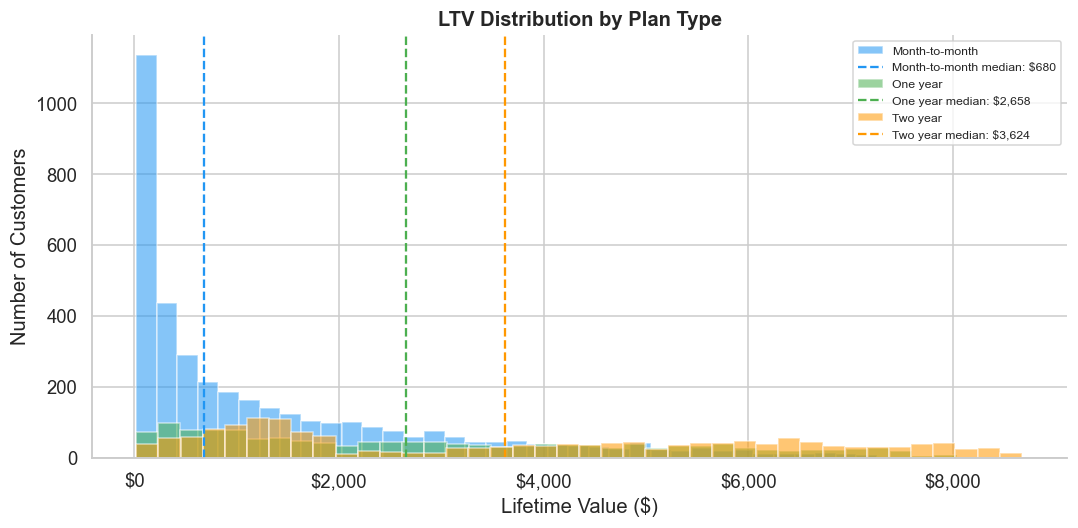

In [10]:
# ── LTV DISTRIBUTION ──────────────────────────────────────────────────────────
df_ltv = df.dropna(subset=["lifetime_value"])   # remove 11 $0-LTV new customers

# Summary stats
ltv_stats = (
    df_ltv.groupby("plan_type", observed=True)["lifetime_value"]
    .agg(["median", "mean", "std", "count"])
    .round(2)
)
print("LTV statistics by plan:")
print(ltv_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
for plan, color in zip(["Month-to-month", "One year", "Two year"],
                        ["#2196F3", "#4CAF50", "#FF9800"]):
    subset = df_ltv[df_ltv["plan_type"] == plan]["lifetime_value"]
    ax.hist(subset, bins=40, alpha=0.55, label=plan, color=color, edgecolor="white")
    ax.axvline(subset.median(), color=color, linestyle="--", linewidth=1.5,
               label=f"{plan} median: ${subset.median():,.0f}")

ax.set_xlabel("Lifetime Value ($)")
ax.set_ylabel("Number of Customers")
ax.set_title("LTV Distribution by Plan Type", fontweight="bold")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../data/processed/fig_ltv_distribution.png", bbox_inches="tight")
plt.show()

---
## 6. Churn Driver Ranking

**Business question**: Which features most predict whether a customer will churn?

We train a simple decision tree — not to predict individual customers, but to rank  
which variables explain churn the most. This is called **feature importance**.

> *This is the intro-to-ML section. The decision tree is just a tool for understanding  
> data structure — not a production model.*

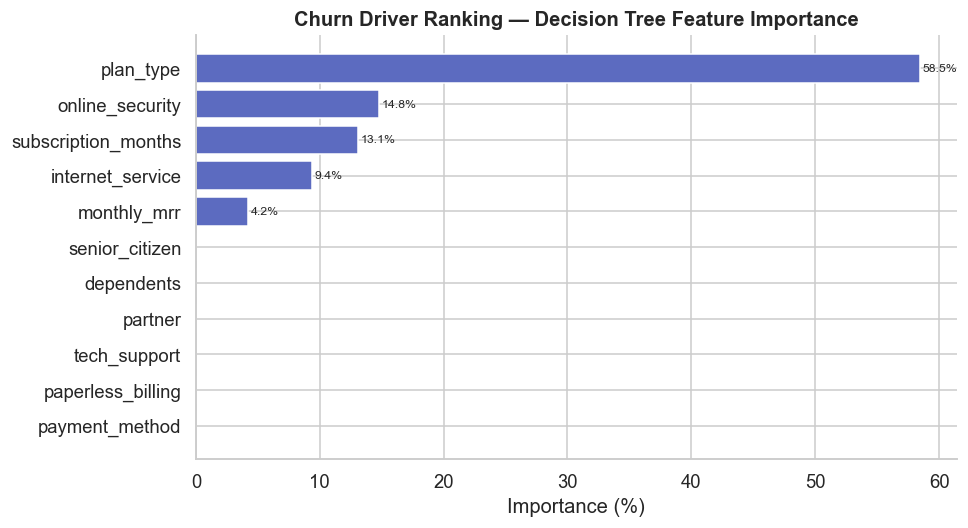


Top 5 churn predictors:
            feature importance
          plan_type      58.5%
    online_security      14.8%
subscription_months      13.1%
   internet_service       9.4%
        monthly_mrr       4.2%


In [11]:
# ── CHURN DRIVER RANKING (Decision Tree Feature Importance) ───────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Select features that are available at signup or within first bill
FEATURES = [
    "subscription_months", "monthly_mrr", "plan_type",
    "internet_service", "online_security", "tech_support",
    "payment_method", "paperless_billing", "senior_citizen",
    "partner", "dependents"
]

df_model = df[FEATURES + ["churned_flag"]].dropna().copy()

# Encode all text columns to numbers (LabelEncoder = maps each category to an integer)
le = LabelEncoder()
for col in df_model.select_dtypes(include="object").columns:
    df_model[col] = le.fit_transform(df_model[col])
# Also encode categorical dtype columns
for col in df_model.select_dtypes(include="category").columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model[FEATURES]
y = df_model["churned_flag"]

# Train a shallow tree (max_depth=4 keeps it interpretable, not overfit)
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X, y)

# Feature importances
importance_df = (
    pd.DataFrame({"feature": FEATURES, "importance": tree.feature_importances_})
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importance_df["feature"], importance_df["importance"] * 100,
               color="#5C6BC0", edgecolor="white")
ax.set_xlabel("Importance (%)")
ax.set_title("Churn Driver Ranking — Decision Tree Feature Importance", fontweight="bold")
for bar in bars:
    if bar.get_width() > 0.5:
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f"{bar.get_width():.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("../data/processed/fig_churn_drivers.png", bbox_inches="tight")
plt.show()

print("\nTop 5 churn predictors:")
print(importance_df.tail(5)[["feature", "importance"]]
      .sort_values("importance", ascending=False)
      .assign(importance=lambda x: x["importance"].map("{:.1%}".format))
      .to_string(index=False))

---
## Executive Summary

### What the data tells us — 3 findings for the Head of Product

**1. Early churn is the #1 risk**  
Customers in their first 6 months churn at **~53%** — nearly 1 in 2. This is 3× the rate of  
mature customers (14%). The product needs a stronger onboarding experience for new accounts.

**2. Month-to-month customers churn 5× more than two-year customers**  
Month-to-month plan churn: ~43%. Two-year plan churn: ~3%.  
Increasing the number of customers on annual/multi-year plans is the highest-leverage retention lever.

**3. Electronic check users churn at 45% — twice the rate of auto-pay users**  
Customers who pay by electronic check may be less committed or experiencing more friction.  
Nudging these customers toward automatic payment methods could improve retention.

---

### Next step: Was the A/B test worth it?
→ See `02_ab_test.ipynb` for the statistical analysis of TechFlow's new onboarding page experiment.